# Checkpoint 1
Data preparation (loading the data, processing them into model input
format, and split the data into train, validation and test set with batching)

In [13]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [14]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


In [15]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5") 
train_data, val_data, test_data = dataset.split(0.8, 0.1, 0.1)

In [16]:
batch_size = 8192
# use dataset.collate(...).cache() method to do batching
train_data_loader = train_data.collate(8192).cache()
val_data_loader = val_data.collate(8192).cache()
test_data_loader = test_data.collate(8192).cache()

In [17]:
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([
    net_H,
    net_C,
    net_N,
    net_O
])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [18]:
train_data_batch = next(iter(train_data_loader))

loss_func = nn.MSELoss()
species = train_data_batch['species'].to(device)
coords = train_data_batch['coordinates'].to(device)
true_energies = train_data_batch['energies'].to(device).float()
_, pred_energies = model((species, coords))
loss = loss_func(true_energies, pred_energies)
print(loss)

tensor(0.4188, device='cuda:0', grad_fn=<MseLossBackward0>)


# Checkpoint 2
Network construction and workflow development, demonstrated on small subset of the data

In [12]:
demo_data, _, _ = dataset.split(500 / len(dataset), 0.0, 0.0)
demo_train, demo_val, _ = demo_data.split(0.8, 0.2, 0.0)
print(f"train size: {len(demo_train)} | val size: {len(demo_val)}")

train size: 400 | val size: 100


In [19]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=l2)
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device).float()
                true_energies = train_data_batch['energies'].to(device).float()

                self.optimizer.zero_grad()

                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)
                
                # do a step
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = len(true_energies)/len(train_data)
                train_epoch_loss += batch_loss.item() * batch_importance

            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data, draw_plot=False)
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss)
            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(range(len(train_loss_list)), train_loss_list, label='Train')
            ax.plot(range(len(val_loss_list)), val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("# Batch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device).float()
                true_energies = batch_data['energies'].to(device).float()

                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)

                batch_importance = len(true_energies) / len(data)
                total_loss += batch_loss.item() * batch_importance
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
        return total_loss
        

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 5/5 [00:02<00:00,  2.24it/s]


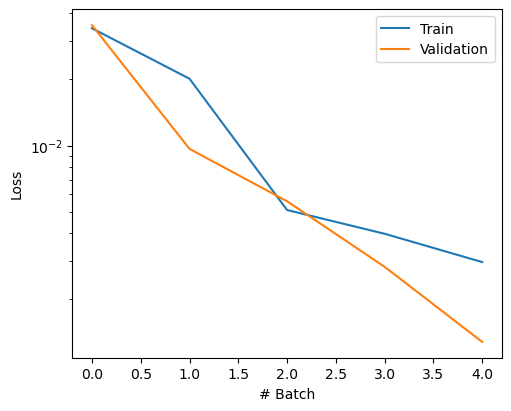

In [14]:
net_H_demo = AtomicNet()
net_C_demo = AtomicNet()
net_N_demo = AtomicNet()
net_O_demo = AtomicNet()
ani_net_demo = torchani.ANIModel([net_H_demo, net_C_demo, net_N_demo, net_O_demo])
model_demo   = nn.Sequential(aev_computer, ani_net_demo).to(device)

trainer_demo = ANITrainer(model_demo, batch_size=128, learning_rate=1e-3, epoch=5, l2=0)
train_losses_demo, val_losses_demo = trainer_demo.train(
    demo_train, demo_val, early_stop=False, draw_curve=True
)

# Checkpoint 3
Regularization strategies, hyperparameter tuning, and choosing final model.

In [20]:
class AtomicNet_A(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.layers(x)

class AtomicNet_B(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.layers(x)

In [21]:
def compute_mae(trainer, data):
    loader = data.collate(trainer.batch_size).cache()
    true_all = []
    pred_all = []
    with torch.no_grad():
        for batch in loader:
            species = batch['species'].to(device)
            coords  = batch['coordinates'].to(device)
            true_e  = batch['energies'].to(device)
            _, pred_e = trainer.model((species, coords))
            true_all.append(true_e.cpu().numpy().flatten())
            pred_all.append(pred_e.cpu().numpy().flatten())
    true_all = np.concatenate(true_all)
    pred_all = np.concatenate(pred_all)
    return np.mean(np.abs(true_all - pred_all)) * hartree2kcalmol

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [01:44<00:00,  5.22s/it]


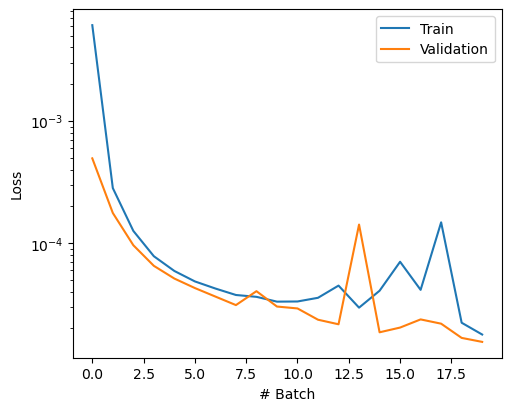

In [22]:
ani_net1 = torchani.ANIModel([AtomicNet_A() for i in range(4)])
model1 = nn.Sequential(aev_computer, ani_net1).to(device)
trainer1 = ANITrainer(model1, batch_size=8192, learning_rate=1e-3, epoch=20, l2=0)
loss1 = trainer1.train(train_data, val_data)

In [23]:
train_mae1 = compute_mae(trainer1, train_data)
val_mae1 = compute_mae(trainer1, val_data)
test_mae1 = compute_mae(trainer1, test_data)
print(f"Model 1 Train: {train_mae1:.2f}, Val: {val_mae1:.2f}, Test: {test_mae1:.2f} kcal/mol")

Model 1 Train: 1.74, Val: 1.75, Test: 1.76 kcal/mol


Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [01:41<00:00,  5.08s/it]


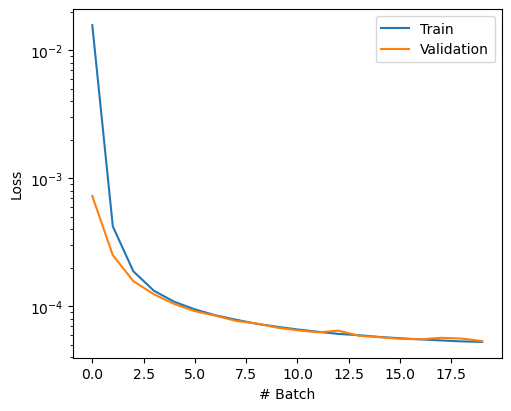

In [24]:
ani_net2 = torchani.ANIModel([AtomicNet_A() for i in range(4)])
model2 = nn.Sequential(aev_computer, ani_net2).to(device)
trainer2 = ANITrainer(model2, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-4)
loss2 = trainer2.train(train_data, val_data)

In [25]:
train_mae2 = compute_mae(trainer2, train_data)
val_mae2 = compute_mae(trainer2, val_data)
test_mae2 = compute_mae(trainer2, test_data)
print(f"Model 2 Train: {train_mae2:.2f}, Val: {val_mae2:.2f}, Test: {test_mae2:.2f} kcal/mol")

Model 2 Train: 2.54, Val: 2.55, Test: 2.56 kcal/mol


Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [01:43<00:00,  5.19s/it]


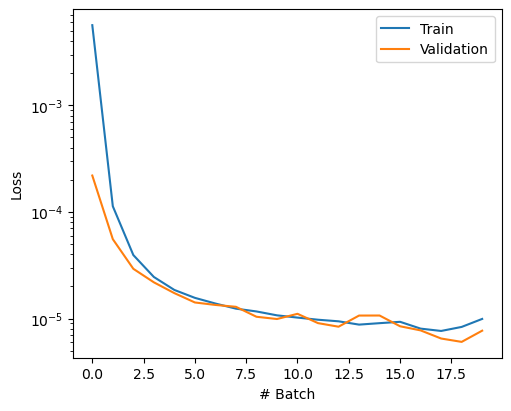

In [26]:
ani_net3 = torchani.ANIModel([AtomicNet_B() for i in range(4)])
model3 = nn.Sequential(aev_computer, ani_net3).to(device)
trainer3 = ANITrainer(model3, batch_size=8192, learning_rate=1e-3, epoch=20, l2=0)
loss3 = trainer3.train(train_data, val_data)

In [27]:
train_mae3 = compute_mae(trainer3, train_data)
val_mae3 = compute_mae(trainer3, val_data)
test_mae3 = compute_mae(trainer3, test_data)
print(f"Model 3 Train: {train_mae3:.2f}, Val: {val_mae3:.2f}, Test: {test_mae3:.2f} kcal/mol")

Model 3 Train: 1.24, Val: 1.25, Test: 1.24 kcal/mol


Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [01:44<00:00,  5.23s/it]


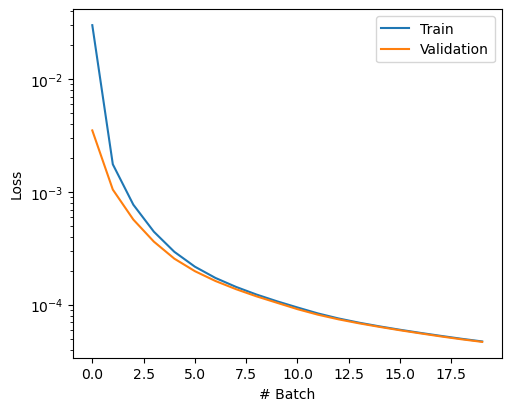

In [28]:
ani_net4 = torchani.ANIModel([AtomicNet_A() for i in range(4)])
model4 = nn.Sequential(aev_computer, ani_net4).to(device)
trainer4 = ANITrainer(model4, batch_size=8192, learning_rate=1e-4, epoch=20, l2=1e-5)
loss4 = trainer4.train(train_data, val_data)

In [29]:
train_mae4 = compute_mae(trainer4, train_data)
val_mae4 = compute_mae(trainer4, val_data)
test_mae4 = compute_mae(trainer4, test_data)
print(f"Model 4 Train: {train_mae4:.2f}, Val: {val_mae4:.2f}, Test: {test_mae4:.2f} kcal/mol")

Model 4 Train: 2.69, Val: 2.70, Test: 2.69 kcal/mol


Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 30/30 [02:45<00:00,  5.50s/it]


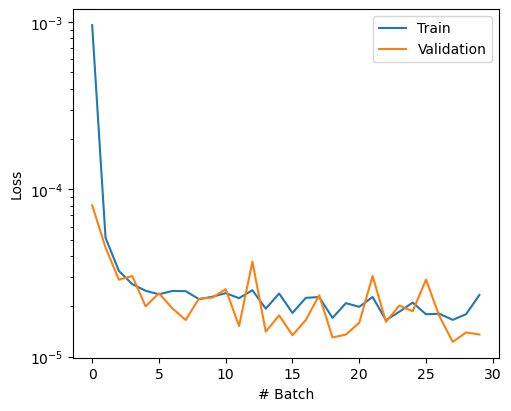

In [30]:
ani_net5 = torchani.ANIModel([AtomicNet_B() for i in range(4)])
model5 = nn.Sequential(aev_computer, ani_net5).to(device)
trainer5 = ANITrainer(model5, batch_size=4096, learning_rate=5e-4, epoch=30, l2=1e-5)
loss5 = trainer5.train(train_data, val_data)

In [31]:
train_mae5 = compute_mae(trainer5, train_data)
val_mae5 = compute_mae(trainer5, val_data)
test_mae5 = compute_mae(trainer5, test_data)
print(f"Model 5 Train: {train_mae5:.2f}, Val: {val_mae5:.2f}, Test: {test_mae5:.2f} kcal/mol")

Model 5 Train: 1.54, Val: 1.54, Test: 1.55 kcal/mol


Model 1 MAE: 1.6087455998977958e-05
Model 2 MAE: 5.22532710543585e-05
Model 3 MAE: 7.663888396705894e-06
Model 4 MAE: 4.6636001098008354e-05
Model 5 MAE: 1.3614489707088711e-05


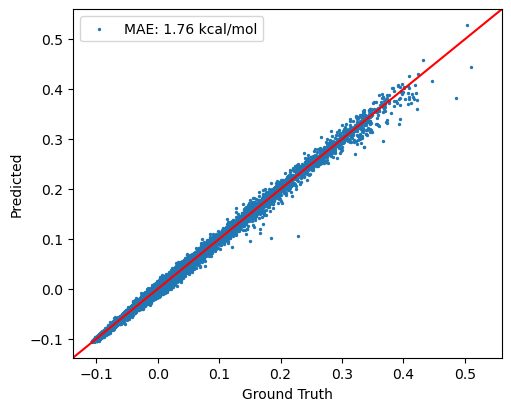

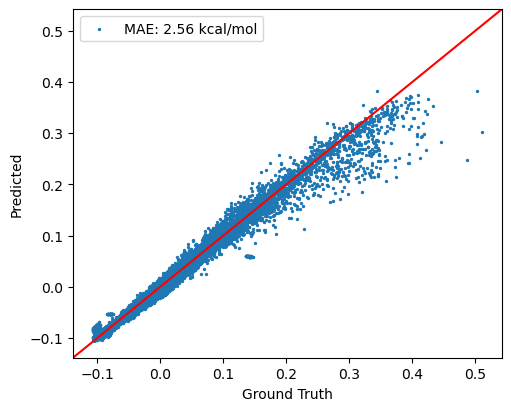

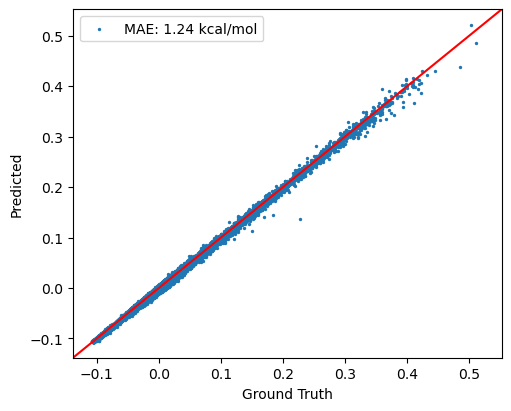

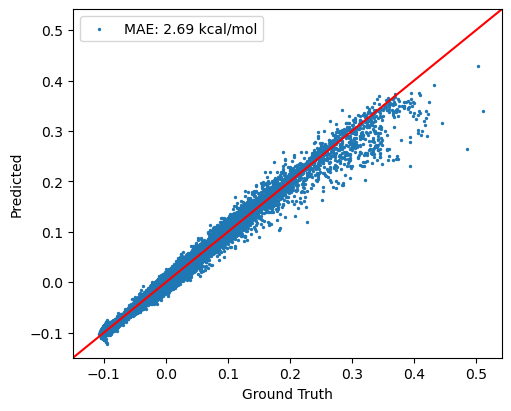

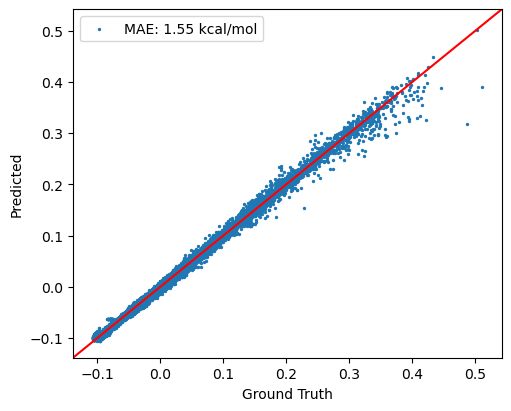

In [33]:
print("Model 1 MAE:", trainer1.evaluate(test_data, draw_plot=True))
print("Model 2 MAE:", trainer2.evaluate(test_data, draw_plot=True))
print("Model 3 MAE:", trainer3.evaluate(test_data, draw_plot=True))
print("Model 4 MAE:", trainer4.evaluate(test_data, draw_plot=True))
print("Model 5 MAE:", trainer5.evaluate(test_data, draw_plot=True))

Model 3 is the best choice because it has the lowest MAE on the parity plot (1.24 kcal/mol), being one of the only model that falls under the 2kcal/mol threshold, and the lowest raw MSE loss (7.66e-06). This model used AtomicNet_B, a learning rate of 1e-3, epoch of 20, and l2=0 as its hyperparameters. The deeper architechure of the AtomicNet_B with two hidden layers compared to A lets it capture the nonlinerar relationship between the AEV features and molecular energies, shown by its consistently superior performance over all models that used AtomicNet_A (Models 1, 2, 4). Compared to model 5, model 3 used a higher learning rate with the full batch size of 8192, leading to a faster and more effective convergence within 20 epochs. The parity plot for Model 3 shows points tightly clustered around the ideal diagonal across the full energy range, with little systematic bias, confirming that the model generalizes well rather than overfitting to the training distribution.

# Checkpoint 4
### Initializing model 3 from checkpoint 3

In [23]:
total_runs = 5
hartree2kcalmol = 627.5094738898777

multi_run_test_maes = []

def compute_mae(trainer, data):
    loader = data.collate(trainer.batch_size).cache()
    true_all = []
    pred_all = []
    with torch.no_grad():
        for batch in loader:
            species = batch['species'].to(device)
            coords  = batch['coordinates'].to(device)
            true_e  = batch['energies'].to(device)
            _, pred_e = trainer.model((species, coords))
            true_all.append(true_e.cpu().numpy().flatten())
            pred_all.append(pred_e.cpu().numpy().flatten())
    true_all = np.concatenate(true_all)
    pred_all = np.concatenate(pred_all)
    return np.mean(np.abs(true_all - pred_all)) * hartree2kcalmol

for run in range(total_runs):
    print("Run", run+1)
    ani_net_run = torchani.ANIModel([AtomicNet_B() for i in range(4)])
    model_run = nn.Sequential(aev_computer, ani_net_run).to(device)
    trainer_run = ANITrainer(model_run, batch_size=8192, learning_rate=1e-3, epoch=20, l2=0)
    train_losses, val_losses = trainer_run.train(train_data, val_data, draw_curve=False)
    
    test_mse = trainer_run.evaluate(test_data, draw_plot=False)
    test_mae = (test_mse ** 0.5) * hartree2kcalmol
    multi_run_test_maes.append(test_mae)
    print(f"Run {run+1} - Test MAE: {test_mae:.4f} kcal/mol")

mean_mae = np.mean(multi_run_test_maes)
std_mae  = np.std(multi_run_test_maes)
print(f"Mean Test MAE: {mean_mae:.4f} kcal/mol")
print(f"Std Test MAE: {std_mae:.4f} kcal/mol")

Run 1
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [01:40<00:00,  5.02s/it]


Run 1 - Test MAE: 1.4848 kcal/mol
Run 2
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [01:51<00:00,  5.57s/it]


Run 2 - Test MAE: 1.9227 kcal/mol
Run 3
Sequential - Number of parameters: 526340
Initialize training data...


...

Run 3 - Test MAE: 1.9953 kcal/mol
Run 4
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [01:35<00:00,  4.79s/it]


Run 4 - Test MAE: 1.5691 kcal/mol
Run 5
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [01:34<00:00,  4.72s/it]


Run 5 - Test MAE: 2.4754 kcal/mol
Mean Test MAE: 1.8895 kcal/mol
Std Test MAE: 0.3527 kcal/mol


### 5-Fold Cross Validation

In [25]:
full_data = torch.utils.data.ConcatDataset([train_data, val_data])
n_total = len(full_data)
fold_size = n_total // 5
indices = list(range(n_total))
cv_val_maes = []
cv_test_maes = []

for fold in range(5):
    print("Fold", fold+1)
    val_indices = indices[fold * fold_size : (fold + 1) * fold_size]
    train_indices = indices[:fold * fold_size] + indices[(fold + 1) * fold_size:]
    fold_train, fold_val, x = dataset.split(len(train_indices) / n_total, fold_size / n_total, 0.0)
    ani_net_cv = torchani.ANIModel([AtomicNet_B() for i in range(4)])
    model_cv = nn.Sequential(aev_computer, ani_net_cv).to(device)
    trainer_cv = ANITrainer(model_cv, batch_size=8192, learning_rate=1e-3, epoch=20, l2=0)
    train_losses, val_losses = trainer_cv.train(fold_train, fold_val, draw_curve=False)
    val_mse = trainer_cv.evaluate(fold_val,  draw_plot=False)
    test_mse = trainer_cv.evaluate(test_data, draw_plot=False)
    
    val_mae  = compute_mae(trainer_cv, fold_val)
    test_mae = compute_mae(trainer_cv, test_data)
    
    cv_val_maes.append(val_mae)
    cv_test_maes.append(test_mae)
    print(f"Fold {fold+1} Val MAE: {val_mae:.4f}, Test MAE: {test_mae:.4f} kcal/mol")

print(f"Val MAE: {np.mean(cv_val_maes):.4f} ± {np.std(cv_val_maes):.4f} kcal/mol")
print(f"Test MAE: {np.mean(cv_test_maes):.4f} ± {np.std(cv_test_maes):.4f} kcal/mol")

Fold 1
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [03:03<00:00,  9.19s/it]


Fold 1 Val MAE: 1.1028, Test MAE: 1.1007 kcal/mol
Fold 2
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [02:24<00:00,  7.22s/it]


Fold 2 Val MAE: 1.3049, Test MAE: 1.3028 kcal/mol
Fold 3
Sequential - Number of parameters: 526340
Initialize training data...


...

Fold 3 Val MAE: 1.1783, Test MAE: 1.1795 kcal/mol
Fold 4
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [02:24<00:00,  7.21s/it]


Fold 4 Val MAE: 1.3801, Test MAE: 1.3795 kcal/mol
Fold 5
Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [02:39<00:00,  8.00s/it]


Fold 5 Val MAE: 1.7233, Test MAE: 1.7152 kcal/mol
Val MAE: 1.3379 ± 0.2155 kcal/mol
Test MAE: 1.3356 ± 0.2129 kcal/mol


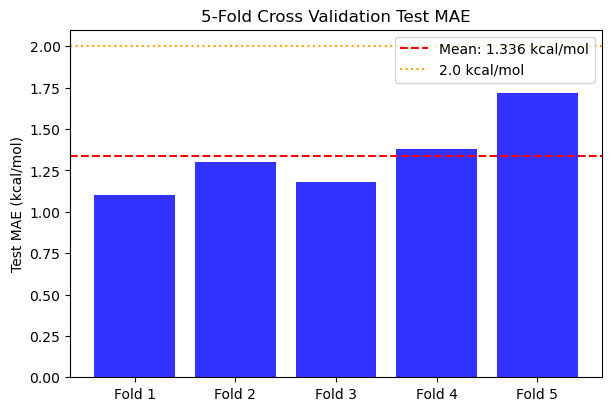

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), constrained_layout=True)
folds = [f"Fold {i+1}" for i in range(5)]
ax.bar(folds, cv_test_maes, color='blue', alpha=0.8)
ax.axhline(np.mean(cv_test_maes), color='red', linestyle='--', label=f'Mean: {np.mean(cv_test_maes):.3f} kcal/mol')
ax.axhline(2.0, color='orange', linestyle=':', label='2.0 kcal/mol')
ax.set_ylabel('Test MAE (kcal/mol)')
ax.set_title('5-Fold Cross Validation Test MAE')
ax.legend()
plt.show()

# Checkpoint 5

Final results by training model 3 on full dataset (train + validation + test combined). Comparison of results to what’s reported in the ANI-1 paper.

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [09:03<00:00, 27.18s/it]


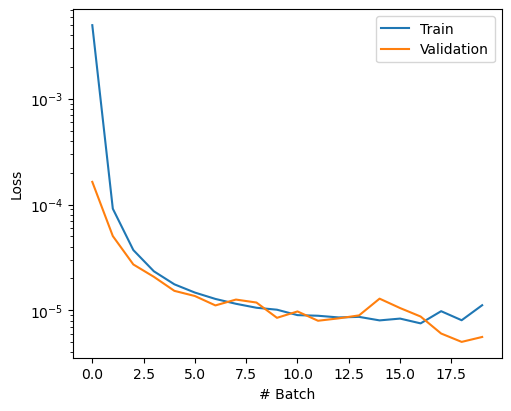

In [13]:
all_data, _, _ = dataset.split(1.0, 0.0, 0.0)

ani_net_final = torchani.ANIModel([AtomicNet_B() for _ in range(4)])
model_final   = nn.Sequential(aev_computer, ani_net_final).to(device)
trainer_final = ANITrainer(model_final, batch_size=8192, learning_rate=1e-3, epoch=20, l2=0)

train_losses, val_losses = trainer_final.train(
    all_data, all_data, early_stop=False, draw_curve=True
)

5.5918805943565334e-06

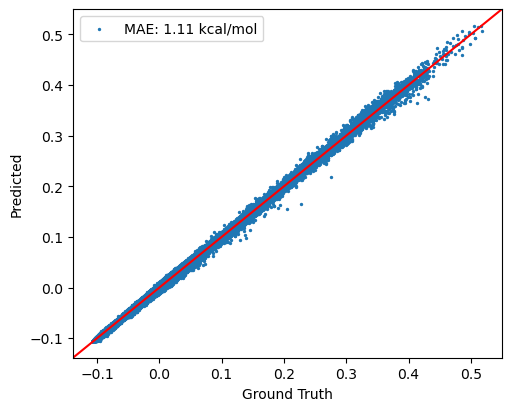

In [14]:
trainer_final.evaluate(all_data, draw_plot=True)

### Comparison to ANI-1 Paper Results

Summary of results compared to the results of the ANI-1 Paper: Smith et al. (2017).

| | ANI-1 Paper | My Final Project |
|---|---|---|
| Dataset | ANI-1 (GDB s01–s08, 17.2M conformations, 57,951 molecules) | GDB s01–s04 (subset) |
| Architecture (per element) | 768 : 128 : 128 : 64 : 1 | 384 : 256 : 128 : 1 |
| Parameters (per element net) | 124,033 | 131,585 |
| Activation | Gaussian | ReLU |
| Optimizer | ADAM (exponential loss) | ADAM (MSE loss) |
| Train RMSE | 1.2 kcal/mol | — |
| Val RMSE | 1.3 kcal/mol | — |
| Test RMSE | 1.3 kcal/mol | — |
| Best Single-Run Test MAE | ~1.3 kcal/mol | 1.24 kcal/mol (Model 3) |
| 5-Fold CV Test MAE | — | 1.336 ± 0.213 kcal/mol |
| Multi-run Mean Test MAE | — | 1.890 ± 0.353 kcal/mol |
| Final Model (all Data) MAE | ~1.3kcal/mol RMSE | 1.11 kcal/mol |

Training the final production model on the full dataset (train + validation + test combined) returned a MAE of 1.11 kcal/mol, which is below the ANI-1 paper's reported RMSE of 1.3 kcal/mol on the same metric scale. The single-run test MAE of 1.24 kcal/mol that used Model 3 is also below this RMSE value, further supporting the final model choice. The learning curve shows convergence that is smooth and consistent of both train and validation loss over 20 epochs with no signs of overfitting. The parity plot also shows points tightly clustered around the y=x diagonal line across the full energy range. The multi-run mean of 1.89 kcal/mol shows the variance that comes from random initialization when trained on the train-only split (smaller dataset), which is fixed by using all of the data that is available. The model trained on GDB s01–s04 achieves competitive accuracy with the original ANI-1 potential despite using a much smaller data subset, clearly showing that the AEV-based architecture is effective even with a smaller subset of data.